<a href="https://colab.research.google.com/github/devdavinchi/2509455_devRai_final/blob/main/2509455_devRai_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Housing Price Prediction
## Regression Analysis
### Herald College - 5CS037

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFE, SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
print('Libraries imported!')

Libraries imported!


## 2. Load Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab/housing.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 3. EDA

In [ ]:
print('Missing values:')
print(df.isnull().sum())
df = df.dropna()
print(f'\nShape after dropping nulls: {df.shape}')

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Shape after dropping nulls: (20433, 10)


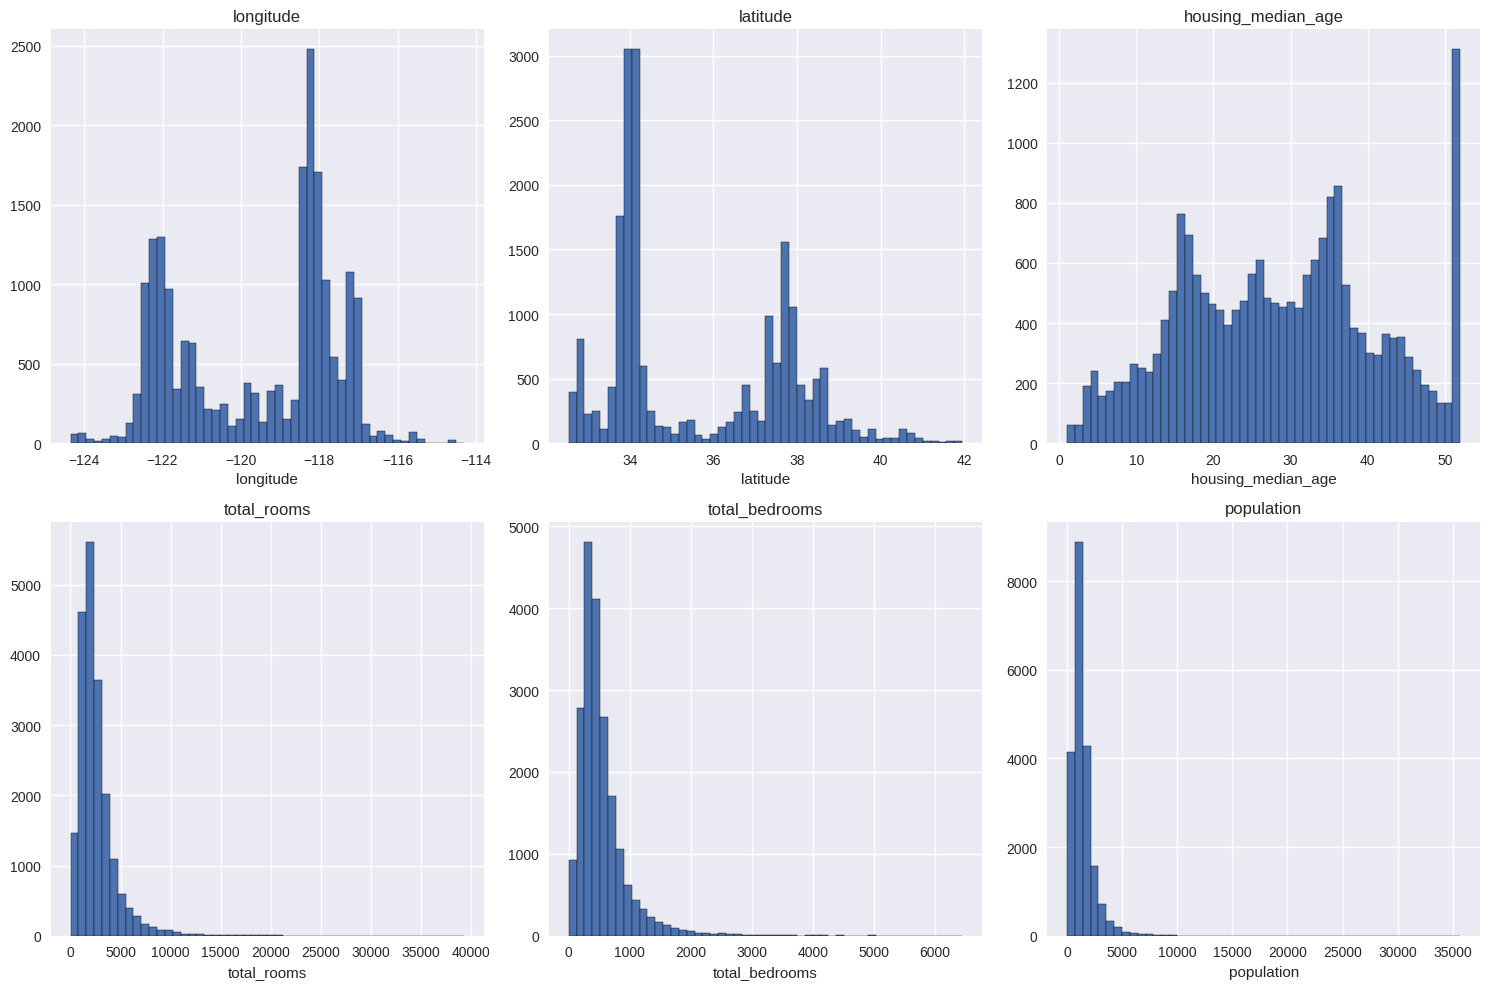

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
num_cols = df.select_dtypes(include=[np.number]).columns[:6]
for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col], bins=50, edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel(col)
plt.tight_layout()
plt.show()

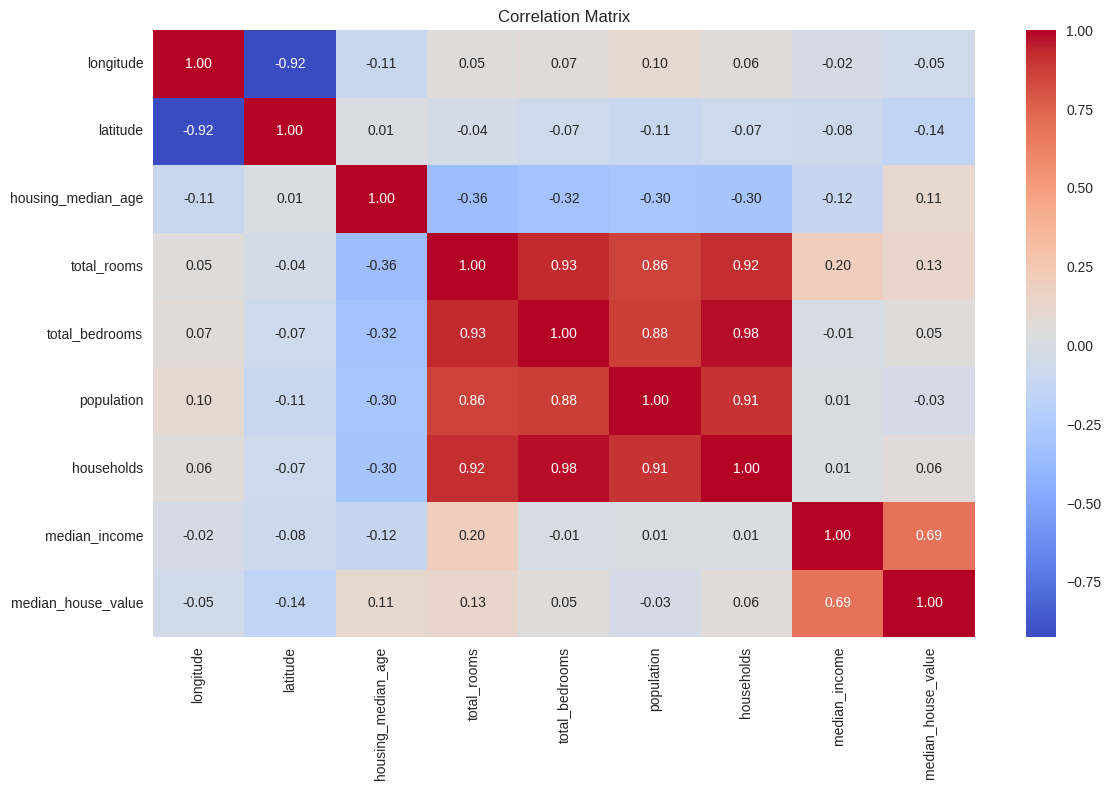

In [ ]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [ ]:
df_processed = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
X = df_processed.drop('median_house_value', axis=1)
y = df_processed['median_house_value']
print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (20433, 12), y shape: (20433,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (16346, 12), Test: (4087, 12)


## 5. Neural Network

In [ ]:
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam',
                          alpha=0.001, max_iter=500, random_state=42, early_stopping=True, verbose=True)
print('Training Neural Network...')
nn_model.fit(X_train_scaled, y_train)

Training Neural Network...
Iteration 1, loss = 27991775774.22100449
Validation score: -3.254005
Iteration 2, loss = 27933957730.95949936
Validation score: -3.229012
Iteration 3, loss = 27490848081.30011368
Validation score: -3.091954
Iteration 4, loss = 25858433820.97322083
Validation score: -2.690654
Iteration 5, loss = 22110586629.22016525
Validation score: -1.911883
Iteration 6, loss = 16230694719.08764648
Validation score: -0.909926
Iteration 7, loss = 10296595136.64336395
Validation score: -0.132268
Iteration 8, loss = 6720083089.88264179
Validation score: 0.191455
Iteration 9, loss = 5404942296.94026661
Validation score: 0.288121
Iteration 10, loss = 4887375071.67326832
Validation score: 0.335603
Iteration 11, loss = 4554041036.12258434
Validation score: 0.370921
Iteration 12, loss = 4295485881.32266903
Validation score: 0.399127
Iteration 13, loss = 4082443839.97052288
Validation score: 0.423574
Iteration 14, loss = 3900090523.16347694
Validation score: 0.445222
Iteration 15, lo

MLPRegressor(alpha=0.001, early_stopping=True, hidden_layer_sizes=(100, 50, 25),
             max_iter=500, random_state=42, verbose=True)

In [ ]:
y_pred_nn_train = nn_model.predict(X_train_scaled)
y_pred_nn_test = nn_model.predict(X_test_scaled)
nn_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_nn_train))
nn_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn_test))
nn_test_mae = mean_absolute_error(y_test, y_pred_nn_test)
nn_test_r2 = r2_score(y_test, y_pred_nn_test)
print(f'NN Train RMSE: {nn_train_rmse:.2f}')
print(f'NN Test RMSE: {nn_test_rmse:.2f}')
print(f'NN Test MAE: {nn_test_mae:.2f}')
print(f'NN Test R²: {nn_test_r2:.4f}')

NN Train RMSE: 58423.74
NN Test RMSE: 60050.77
NN Test MAE: 41782.03
NN Test R²: 0.7363


## 6. Classical Models

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
print(f'Linear Regression - RMSE: {lr_rmse:.2f}, R²: {lr_r2:.4f}')

Linear Regression - RMSE: 69297.72, R²: 0.6488


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)
print(f'Random Forest - RMSE: {rf_rmse:.2f}, R²: {rf_r2:.4f}')

Random Forest - RMSE: 48777.79, R²: 0.8260


## 7. Hyperparameter Tuning

In [ ]:
lr_params = {'fit_intercept': [True, False], 'copy_X': [True, False]}
lr_grid = GridSearchCV(LinearRegression(), lr_params, cv=5, scoring='r2', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
print(f'Best LR params: {lr_grid.best_params_}')
print(f'Best CV R²: {lr_grid.best_score_:.4f}')

Best LR params: {'copy_X': True, 'fit_intercept': True}
Best CV R²: 0.6425


In [ ]:
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20, None],
             'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
print('Tuning RF...')
rf_grid.fit(X_train_scaled, y_train)
print(f'Best RF params: {rf_grid.best_params_}')
print(f'Best CV R²: {rf_grid.best_score_:.4f}')

Tuning RF...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.8182


## 8. Feature Selection

In [ ]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=8)
rfe.fit(X_train_scaled, y_train)
selected_features = X_train_scaled.columns[rfe.support_].tolist()
print(f'Selected features: {selected_features}')
X_train_rfe = X_train_scaled[selected_features]
X_test_rfe = X_test_scaled[selected_features]

Selected features: ['longitude', 'latitude', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND']


## 9. Final Models

In [ ]:
final_lr = LinearRegression(**lr_grid.best_params_)
final_lr.fit(X_train_rfe, y_train)
y_pred_final_lr = final_lr.predict(X_test_rfe)
final_lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final_lr))
final_lr_r2 = r2_score(y_test, y_pred_final_lr)
final_lr_cv = cross_val_score(final_lr, X_train_rfe, y_train, cv=5, scoring='r2').mean()
print(f'Final LR - RMSE: {final_lr_rmse:.2f}, R²: {final_lr_r2:.4f}, CV: {final_lr_cv:.4f}')

Final LR - RMSE: 70196.46, R²: 0.6397, CV: 0.6310


In [ ]:
final_rf = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
final_rf.fit(X_train_rfe, y_train)
y_pred_final_rf = final_rf.predict(X_test_rfe)
final_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final_rf))
final_rf_r2 = r2_score(y_test, y_pred_final_rf)
final_rf_cv = cross_val_score(final_rf, X_train_rfe, y_train, cv=5, scoring='r2').mean()
print(f'Final RF - RMSE: {final_rf_rmse:.2f}, R²: {final_rf_r2:.4f}, CV: {final_rf_cv:.4f}')

Final RF - RMSE: 48830.75, R²: 0.8256, CV: 0.8214


## 10. Final Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Features': [len(selected_features), len(selected_features)],
    'CV Score': [final_lr_cv, final_rf_cv],
    'Test RMSE': [final_lr_rmse, final_rf_rmse],
    'Test R²': [final_lr_r2, final_rf_r2]
})
print(comparison)
best_model = comparison.loc[comparison['Test R²'].idxmax(), 'Model']
print(f'\nBest Model: {best_model}')

               Model  Features  CV Score     Test RMSE   Test R²
0  Linear Regression         8  0.631017  70196.462711  0.639673
1      Random Forest         8  0.821421  48830.754023  0.825637

Best Model: Random Forest


## 11. Conclusion

In [ ]:
print('PROJECT SUMMARY')
print('='*60)
print(f'Dataset: California Housing ({df.shape[0]:,} records)')
print(f'Models: Neural Network, Linear Regression, Random Forest')
print(f'Feature Selection: RFE ({len(selected_features)} features)')
print(f'Best Model: {best_model}')
print('='*60)

PROJECT SUMMARY
Dataset: California Housing (20,433 records)
Models: Neural Network, Linear Regression, Random Forest
Feature Selection: RFE (8 features)
Best Model: Random Forest
